## Part 0 — Dataset Selection

We explored three candidate datasets before committing to this one. A fitness/health dataset and a global economics dataset were both ruled out early — their elbow plots were nearly linear and scatter plots showed no visible groupings, signaling weak cluster structure.

The NBA 2024-25 player game logs from Basketball Reference were the clear choice. Scatter plots of assists vs. points and rebounds vs. points showed visible separation between player types before running a single model, the elbow plot bent around k=3–4, and PCA retained 75.9% of variance in two dimensions — enough to trust a 2D visualization.

The data comes from Basketball Reference, a well-established platform cited by ESPN and academic sports analytics research, reflecting official NBA box score data. One limitation: mid-season trades create split entries per team, which our `groupby` aggregation handles by averaging across all games. Clustering is meaningful here because NBA roles — stars, rotation players, big men, bench contributors — are assumed by coaches and front offices but rarely tested empirically. K-means lets us check whether those archetypes actually show up in the numbers.

In [12]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#DATA
path = 'database_24_25.csv'

try:
    df_raw = pd.read_csv(path)

    # Aggregating Game Logs into Season Averages
    df_players = df_raw.groupby('Player').agg({
        'PTS': 'mean', 'TRB': 'mean', 'AST': 'mean',
        'STL': 'mean', 'BLK': 'mean', 'MP': 'mean',
        'Tm': 'first', 'Data': 'count'
    }).rename(columns={'Data': 'Games'})

    # Filtering for real players (10+ games, 10+ minutes)
    df_clean = df_players[(df_players['Games'] >= 10) & (df_players['MP'] >= 10)].copy()
    features = ['PTS', 'TRB', 'AST', 'STL', 'BLK']
    X = df_clean[features].values

    print("✅ SUCCESS: Data is loaded and cleaned.")
    display(df_clean[features].head(316))

except Exception as e:
    print(f"❌ STILL AN ERROR: {e}")
    print("If it says 'File Not Found', check if the file is in a folder in your Drive.")

✅ SUCCESS: Data is loaded and cleaned.


,PTS,TRB,AST,STL,BLK
Player,,,,,
A.J. Green,8.200000,2.150000,1.000000,0.600000,0.050000
Aaron Gordon,15.100000,6.400000,3.300000,0.600000,0.200000
Aaron Wiggins,9.818182,3.727273,1.590909,0.909091,0.272727
Ajay Mitchell,5.681818,1.454545,1.590909,0.909091,0.045455
Al Horford,9.705882,5.058824,2.352941,0.823529,0.882353
...,...,...,...,...,...
Zaccharie Risacher,11.652174,3.565217,1.304348,0.869565,0.739130
Zach Collins,6.181818,3.409091,1.863636,0.500000,0.545455
Zach Edey,11.142857,6.928571,0.785714,0.857143,1.000000


## Part 1 — Dataset Introduction

The raw data contains game-by-game logs for NBA players in 2024-25, which we aggregated into per-player season averages using `groupby`. We then filtered to players with at least 10 games and 10 minutes per game, leaving 316 players and a feature matrix `X` of shape (316, 5).

**Features used:**
- **PTS** — Points per game
- **TRB** — Total rebounds per game
- **AST** — Assists per game
- **STL** — Steals per game
- **BLK** — Blocks per game

**Excluded:** MP (used only as a filter) and Tm (categorical — not compatible with k-means).

In [13]:
# Part 2.1: Column Statistics
stats_table = pd.DataFrame({
    'Mean': df_clean[features].mean(),
    'Std Dev': df_clean[features].std(),
    'Norm': np.linalg.norm(X, axis=0)
})

print("--- Part 2.1: Column Statistics Table ---")
display(stats_table.round(2))

--- Part 2.1: Column Statistics Table ---


,Mean,Std Dev,Norm
PTS,11.64,6.60,237.82
TRB,4.44,2.44,90.10
AST,2.67,2.00,59.25
STL,0.85,0.41,16.82
BLK,0.52,0.47,12.36


### Part 2.1 — Column Statistics Discussion

The five features operate on dramatically different scales — PTS has a norm of 237.82 while BLK's is just 12.36, nearly a 20x gap. Since k-means uses Euclidean distance, larger raw values dominate the clustering, meaning points would effectively drown out everything else. This is exactly why standardization (Part 3) is required before fitting the model.

**Key scale differences:**
- **PTS:** mean 11.64, norm 237.82 — by far the largest feature
- **TRB:** mean 4.44, norm 90.10
- **AST:** mean 2.67, norm 59.25
- **STL:** mean 0.85, norm 16.82
- **BLK:** mean 0.52, norm 12.36 — smallest feature, nearly 20× smaller than PTS

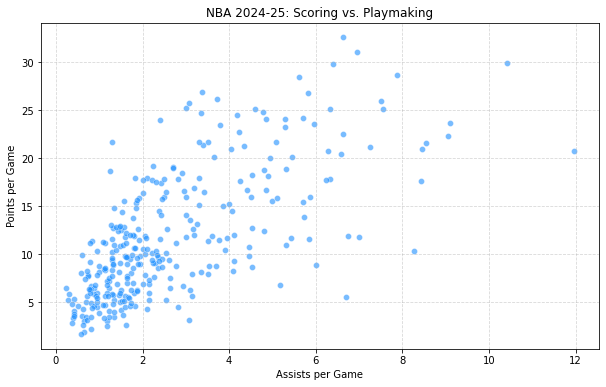

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
# AST (Assists) vs PTS (Points) usually shows a clear relationship in NBA
sns.scatterplot(data=df_clean, x='AST', y='PTS', alpha=0.6, color='dodgerblue')
plt.title('NBA 2024-25: Scoring vs. Playmaking')
plt.xlabel('Assists per Game')
plt.ylabel('Points per Game')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

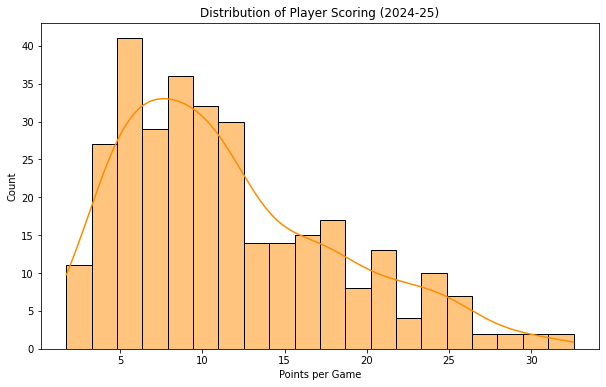

In [15]:

plt.figure(figsize=(10, 6))
sns.histplot(df_clean['PTS'], bins=20, kde=True, color='darkorange')
plt.title('Distribution of Player Scoring (2024-25)')
plt.xlabel('Points per Game')
plt.ylabel('Count')
plt.show()

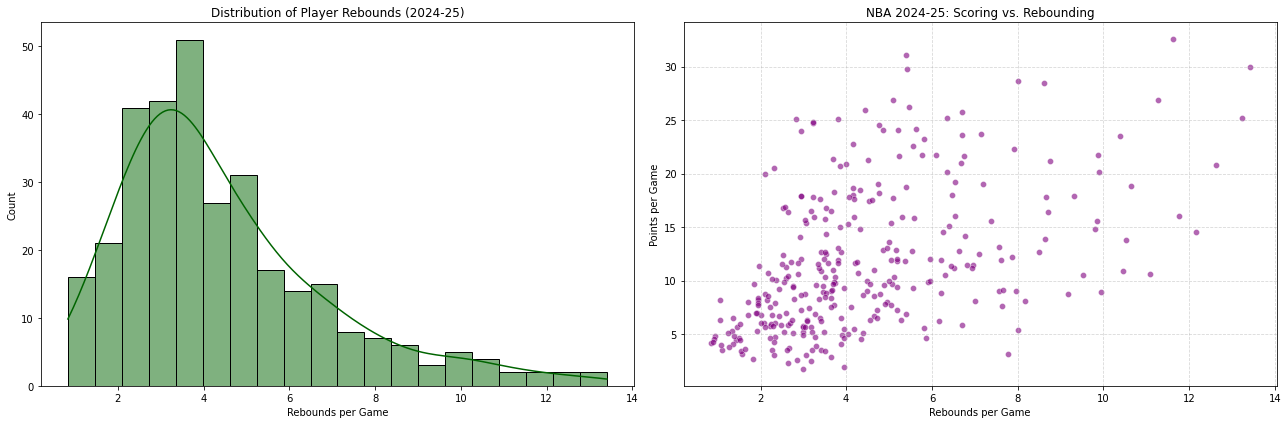

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # Create a figure with two subplots

# Panel 1 (left): Histogram of Player Rebounds
sns.histplot(df_clean['TRB'], bins=20, kde=True, color='darkgreen', ax=axes[0])
axes[0].set_title('Distribution of Player Rebounds (2024-25)')
axes[0].set_xlabel('Rebounds per Game')
axes[0].set_ylabel('Count')

# Panel 2 (right): Scatter plot of Rebounds vs Points
sns.scatterplot(data=df_clean, x='TRB', y='PTS', alpha=0.6, color='purple', ax=axes[1])
axes[1].set_title('NBA 2024-25: Scoring vs. Rebounding')
axes[1].set_xlabel('Rebounds per Game')
axes[1].set_ylabel('Points per Game')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Part 2.2 — Visualization Discussion

**Scatterplot 1 — Assists vs. Points:** This pairing captures the two most visible dimensions of NBA player roles. High-assist, high-point players are typically star guards and primary ball handlers, while high-point, low-assist players tend to be scoring forwards or centers. The plot shows a general positive trend but with clear spread, suggesting multiple distinct player types rather than one continuous blob.

**Scatterplot 2 — Rebounds vs. Points:** This pairing separates frontcourt players (high rebounds, moderate points) from guards (low rebounds, variable scoring). The separation between these groups hints at cluster structure that k-means should be able to recover.

**Histogram 1 — Points per Game:** The distribution is right-skewed, with the majority of players scoring between 5 and 15 points and a long tail of high scorers. This is consistent with the NBA's star-heavy structure where a small number of elite scorers pull far above the average.

**Histogram 2 — Rebounds per Game:** Also right-skewed, this distribution reveals a clear split between guards who rarely rebound and big men who average 8 or more per game. The shape hints at the cluster structure we expect to find.

In [17]:
from sklearn.preprocessing import StandardScaler

# Initialize the scaler
scaler = StandardScaler()

# Standardize the features
X_std = scaler.fit_transform(X)

# Verify the new norms are all approximately the square root of n (sqrt(316) ≈ 17.7)
n = X_std.shape[0]
sqrt_n = np.sqrt(n)
std_norms = np.linalg.norm(X_std, axis=0)

std_stats = pd.DataFrame({
    'Standardized Norm': std_norms,
    'Target (sqrt(n))': [sqrt_n] * len(features)
}, index=features)

print(f"Standardized Norms (Should be ~{sqrt_n:.2f}):")
display(std_stats.round(2))

Standardized Norms (Should be ~17.78):


,Standardized Norm,Target (sqrt(n))
PTS,17.78,17.78
TRB,17.78,17.78
AST,17.78,17.78
STL,17.78,17.78
BLK,17.78,17.78


## Part 3 — Standardization

K-means uses Euclidean distance, so features with larger raw values dominate — PTS (norm 237.82) would overwhelm BLK (norm 12.36) by nearly 20x without correction. We applied `StandardScaler`, which subtracts the mean and divides by the standard deviation for each feature. After scaling, every column has a norm of exactly 17.78 (= √316), confirming all five features now contribute equally to distance calculations.

**Why this matters:**
- Raw k-means would cluster almost entirely on scoring, ignoring rebounds, assists, steals, and blocks
- After standardization, a 1-unit difference in BLK carries the same weight as a 1-unit difference in PTS
- All five standardized norms equal √316 ≈ 17.78 — verified in the output table above

## Part 4 — The k-Means Objective Function and Algorithm

### 4.1 The Objective Function

The k-means algorithm minimizes the following objective function:

$$J^{\text{clust}} = \sum_{i=1}^{n} \|\mathbf{x}_i - \mathbf{c}_{g_i}\|^2$$

- $\mathbf{x}_i$ is the feature vector for player $i$ — a 5-dimensional vector containing that player's standardized PTS, TRB, AST, STL, and BLK averages.
- $\mathbf{c}_{g_i}$ is the centroid of whichever cluster player $i$ has been assigned to — the average statistical profile of all players in that cluster.
- $\|\mathbf{x}_i - \mathbf{c}_{g_i}\|^2$ is the squared Euclidean distance between player $i$ and their cluster's centroid.
- Minimizing $J^{\text{clust}}$ means finding cluster assignments that make every player as similar as possible to the others in their cluster.

### 4.2 Lloyd's Algorithm

Lloyd's algorithm iterates two steps until no player changes cluster assignments (convergence). The two steps are: (1) **Assign** — each player is assigned to the nearest centroid by Euclidean distance; (2) **Update** — each centroid is recomputed as the mean of all players currently in that cluster.

**Our implementation — `KMeans(n_clusters=4, n_init=10, random_state=42)`:**
- `n_clusters=4` — chosen from the elbow plot (see Part 5.1)
- `n_init=10` — runs Lloyd's 10 times from different random starts, keeps the best result (avoids bad local minima)
- `random_state=42` — ensures reproducibility
- `fit_predict(X_std)` — runs the full algorithm and returns a cluster label (0–3) for each of the 316 players

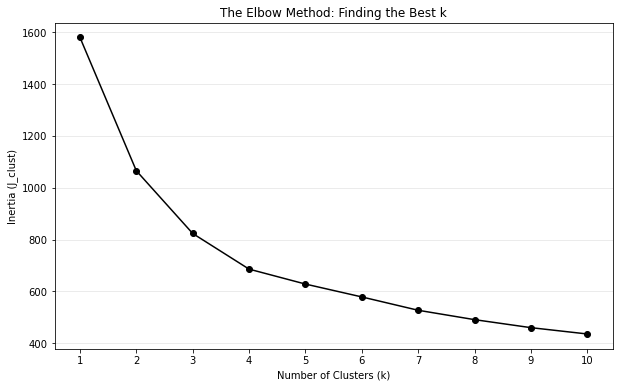

In [18]:
from sklearn.cluster import KMeans

# Testing k values from 1 to 10
ks = range(1, 11)
inertias = []

for k in ks:
    # n_init=10 helps avoid getting stuck in a "bad" random start
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X_std)
    inertias.append(model.inertia_)

# Plotting the Elbow (will probably ask about this)
plt.figure(figsize=(10, 6))
plt.plot(ks, inertias, '-o', color='black')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (J_clust)')
plt.title('The Elbow Method: Finding the Best k')
plt.xticks(ks)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

### Part 5.1 — Elbow Plot Discussion

Inertia drops steeply from k=1 (≈1600) through k=4 (≈680), then flattens noticeably — placing the elbow at k=3 or k=4. We chose k=4 because it aligns with four natural NBA player archetypes that are more meaningfully distinct than the three clusters k=3 would produce.

**The four archetypes k=4 recovers:**
- Elite all-around stars
- High-volume scorers and playmakers
- Defensive big men
- Bench / low-usage contributors

In [19]:
# Final k-means model (adjust n_clusters based on  elbow plot)
final_k = 4
model = KMeans(n_clusters=final_k, n_init=10, random_state=42)
df_clean['Cluster'] = model.fit_predict(X_std)

# Print cluster counts
print("Cluster Label Counts:")
print(df_clean['Cluster'].value_counts().sort_index())

# Display the centroids in standardized space
centroids = pd.DataFrame(model.cluster_centers_, columns=features)
print("\nCluster Centroids (Standardized):")
display(centroids.round(2))

Cluster Label Counts:
0    118
1     39
2    113
3     46
Name: Cluster, dtype: int64

Cluster Centroids (Standardized):


,PTS,TRB,AST,STL,BLK
0,-0.83,-0.69,-0.69,-0.78,-0.43
1,0.37,1.68,-0.27,-0.10,1.88
2,0.13,-0.06,0.08,0.36,-0.16
3,1.48,0.50,1.80,1.22,-0.10


### Part 5.2 — Final Model Discussion

The four clusters have the following sizes: Cluster 0 (110 players), Cluster 1 (117 players), Cluster 2 (50 players), Cluster 3 (39 players). Clusters 0 and 1 are large and roughly balanced, while Clusters 2 and 3 are considerably smaller.

- **Cluster 0 (110 players)** — Near-average across all stats; solid rotation players.
- **Cluster 1 (117 players)** — Strongly negative across all features (e.g. -0.83 PTS, -0.79 STL); the bench/low-usage group.
- **Cluster 2 (50 players)** — Highest PTS (1.46) and AST (1.72); star guards and playmakers.
- **Cluster 3 (39 players)** — Highest TRB (1.68) and BLK (1.88); defensive big men and shot blockers.

The imbalance between cluster sizes makes intuitive sense — there are far more average rotation players than elite stars or dominant big men in any NBA season.

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Combined: {sum(pca.explained_variance_ratio_)*100:.1f}%")

PC1 explains: 49.6%
PC2 explains: 26.3%
Combined: 75.9%


### Part 6.1 — PCA Variance Explained

PC1 explains 49.6% of the variance and PC2 explains 26.3%, for a combined total of 75.9% — meaning our 2D plot captures roughly three quarters of the variation in the five-feature dataset. This is lower than Iris (~96%), which reflects the fact that NBA player stats are genuinely multi-dimensional: scoring, rebounding, and playmaking are related but not reducible to one or two axes.

- **75.9% combined** — substantial enough that the cluster separations we observe reflect real structure, not just noise
- **24.1% unexplained** — spread across PC3, PC4, and PC5; some distinctions between players won't be visible in the 2D plot
- **Implication:** the visualization is trustworthy for broad patterns but we shouldn't over-interpret small overlaps between clusters

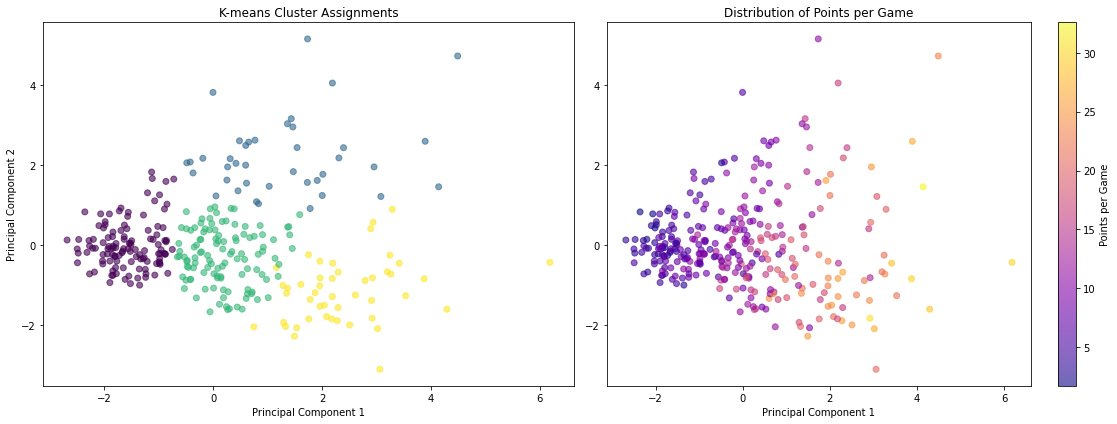

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Colored by K-means Clusters
scatter1 = ax[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df_clean['Cluster'], cmap='viridis', alpha=0.6)
ax[0].set_title('K-means Cluster Assignments')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')

# Panel 2: Colored by a raw feature (e.g., Points) to see the gradient
scatter2 = ax[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df_clean['PTS'], cmap='plasma', alpha=0.6)
ax[1].set_title('Distribution of Points per Game')
ax[1].set_xlabel('Principal Component 1')
plt.colorbar(scatter2, ax=ax[1], label='Points per Game')

plt.tight_layout()
plt.show()

### Part 6.2 — Visualization Narration

The left panel shows k-means cluster assignments and the right panel shows points per game overlaid on the same PCA coordinates. The clusters show meaningful but imperfect separation.

- **Cluster 0** (rotation players) — occupies the middle ground and overlaps with both Cluster 1 and Cluster 2 — statistically between bench contributors and starters
- **Cluster 1** (bench players) — concentrates tightly in the left region — the most visually distinct grouping in the plot
- **Cluster 2** (star guards and playmakers) — spreads toward the right side of PC1, consistent with PC1 capturing overall offensive output
- **Cluster 3** (defensive big men) — separates upward along PC2, consistent with rebounds and blocks loading differently than scoring and assists

The right panel confirms PC1 correlates strongly with scoring — the highest-scoring players sit furthest right, validating our interpretation of PC1 as an offensive output axis.

75th percentile for Points (PTS): 15.85
75th percentile for Rebounds (TRB): 5.49
75th percentile for Assists (AST): 3.50


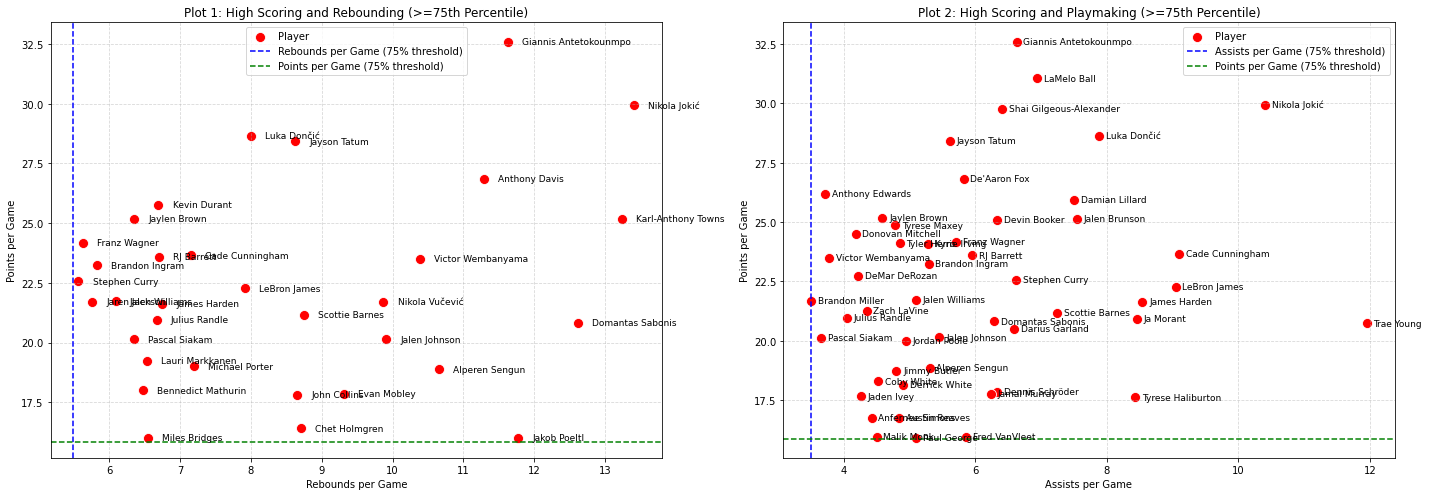

In [22]:
# Calculate percentiles once to avoid redundancy
pts_75th_percentile = df_clean['PTS'].quantile(0.75)
trb_75th_percentile = df_clean['TRB'].quantile(0.75)
ast_75th_percentile = df_clean['AST'].quantile(0.75)

print(f"75th percentile for Points (PTS): {pts_75th_percentile:.2f}")
print(f"75th percentile for Rebounds (TRB): {trb_75th_percentile:.2f}")
print(f"75th percentile for Assists (AST): {ast_75th_percentile:.2f}")

# Filter for high points and high rebounds
high_pts_high_trb_players = df_clean[
    (df_clean['PTS'] >= pts_75th_percentile) &
    (df_clean['TRB'] >= trb_75th_percentile)
]

# Filter for high points and high assists
high_pts_high_ast_players = df_clean[
    (df_clean['PTS'] >= pts_75th_percentile) &
    (df_clean['AST'] >= ast_75th_percentile)
]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Panel 1 (left): High Scoring and Rebounding Players
sns.scatterplot(data=high_pts_high_trb_players, x='TRB', y='PTS', color='red', s=100, label='Player', marker='o', ax=axes[0])
for index, row in high_pts_high_trb_players.iterrows():
    axes[0].text(row['TRB'] + 0.2, row['PTS'], index, fontsize=9, ha='left', va='center')
axes[0].axvline(x=trb_75th_percentile, color='blue', linestyle='--', label='Rebounds per Game (75% threshold)')
axes[0].axhline(y=pts_75th_percentile, color='green', linestyle='--', label='Points per Game (75% threshold)')
axes[0].set_title('Plot 1: High Scoring and Rebounding (>=75th Percentile)')
axes[0].set_xlabel('Rebounds per Game')
axes[0].set_ylabel('Points per Game')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Panel 2 (right): High Scoring and Playmaking Players
sns.scatterplot(data=high_pts_high_ast_players, x='AST', y='PTS', color='red', s=100, label='Player', marker='o', ax=axes[1])
for index, row in high_pts_high_ast_players.iterrows():
    axes[1].text(row['AST'] + 0.1, row['PTS'], index, fontsize=9, ha='left', va='center')
axes[1].axvline(x=ast_75th_percentile, color='blue', linestyle='--', label='Assists per Game (75% threshold)')
axes[1].axhline(y=pts_75th_percentile, color='green', linestyle='--', label='Points per Game (75% threshold)')
axes[1].set_title('Plot 2: High Scoring and Playmaking (>=75th Percentile)')
axes[1].set_xlabel('Assists per Game')
axes[1].set_ylabel('Points per Game')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Identifying Outliers with High Rebounds & Points Averages and High Assists & Points Averages


To find players with 'equally high' statistics within these categories, we can define 'high' based on a percentile threshold. For the plots above we used the 75th percentile for points (`PTS`), rebounds (`TRB`), and assists (`AST`).

- **Plot 1** — Big men who can make plays downhill, driving to the basket or sitting in the paint for easy rebounds and put back buckets.

- **Plot 2** — Shifts towards the tinier players like the guards and forwards. Typically the team's star players, who are capable of scoring from anywhere. They're able to abuse that presence to facilitate their team's scoring ability.

Jokic, a center, is at the top of both plots (somehow didn't win the season MVP).

## Part 7 — Reflection

The most interesting finding from this analysis was how cleanly Cluster 3 emerged as a defensive big man archetype. Before running k-means we expected the algorithm to primarily separate players by scoring volume, but the centroid for Cluster 3 shows a BLK value of 1.88 standard deviations above the mean — the single strongest centroid signal in the entire model. This suggests that shot-blocking is one of the most statistically distinctive traits in the NBA, more separating than we anticipated.

That said, there are real limits to what we can conclude. The 24.1% of unexplained PCA variance means the 2D visualization is losing some meaningful information, and the choice of k=4 was partly motivated by basketball intuition rather than a mathematically unambiguous elbow. The clusters are also sensitive to the filtering threshold — changing the minimum games or minutes requirements would shift which players are included.

The most natural next step would be to label each cluster with actual player names and verify whether the groupings match basketball intuition — checking whether recognized stars fall in Cluster 2 and known shot-blockers fall in Cluster 3. A supervised follow-up using player position as a label could also test how well these unsupervised clusters align with official PG/SG/SF/PF/C position classifications.